# Loan Default Prediction — Exploratory Data Analysis
**Competition:** Kaggle Playground Series S5E11 — Predicting Loan Payback  
**Target:** `loan_paid_back` (1 = paid back, 0 = default)  
**Metric:** AUC-ROC  
**Training pipeline:** `src/train.py`

## 1. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#8b949e',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'figure.dpi':       120,
})

TARGET_COL = 'loan_paid_back'
TRAIN_PATH = '../data/train.csv'
TEST_PATH  = '../data/test.csv'

## 2. Load Data

In [2]:
df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

print(f'Train : {df_train.shape[0]:,} rows  x  {df_train.shape[1]} cols')
print(f'Test  : {df_test.shape[0]:,} rows  x  {df_test.shape[1]} cols')
df_train.head()

Train : 593,994 rows  x  13 cols
Test  : 254,569 rows  x  12 cols


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.9900,0.0840,736,2528.4200,13.6700,Female,Single,High School,Self-employed,Other,C3,1.0000
1,1,22108.0200,0.1660,636,4593.1000,12.9200,Male,Married,Master's,Employed,Debt consolidation,D3,0.0000
2,2,49566.2000,0.0970,694,17005.1500,9.7600,Male,Single,High School,Employed,Debt consolidation,C5,1.0000
3,3,46858.2500,0.0650,533,4682.4800,16.1000,Female,Single,High School,Employed,Debt consolidation,F1,1.0000
4,4,25496.7000,0.0530,665,12184.4300,10.2100,Male,Married,High School,Employed,Other,D1,1.0000


## 3. Schema & Data Types

In [3]:
df_train.dtypes.to_frame('dtype').assign(
    nunique=df_train.nunique(),
    null_pct=(df_train.isnull().mean() * 100).round(2)
)

,dtype,nunique,null_pct
id,int64,593994,0.0000
annual_income,float64,119728,0.0000
debt_to_income_ratio,float64,526,0.0000
credit_score,int64,399,0.0000
loan_amount,float64,111570,0.0000
interest_rate,float64,1454,0.0000
gender,str,3,0.0000
marital_status,str,4,0.0000
education_level,str,5,0.0000
employment_status,str,5,0.0000


## 4. Target Distribution

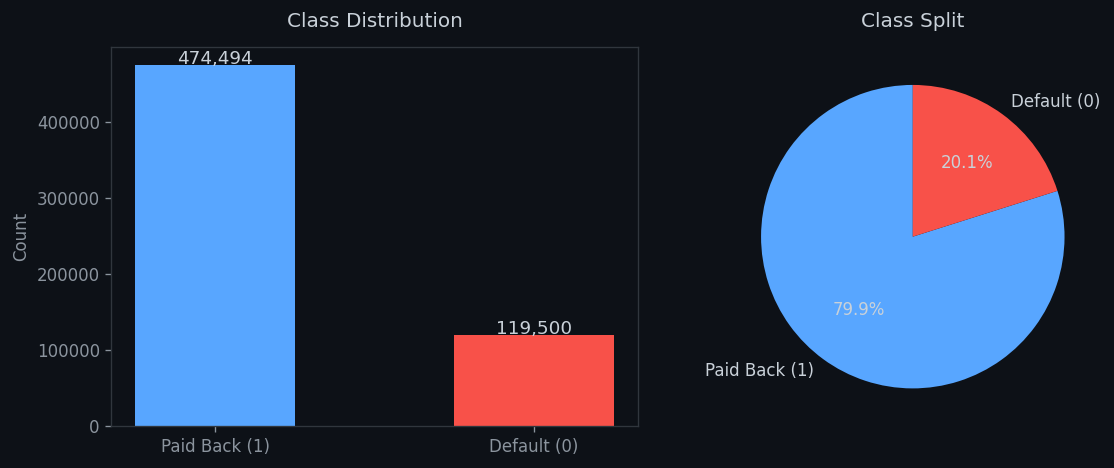

Paid back : 474,494  (79.9%)
Default   : 119,500  (20.1%)
Ratio     : 4.0:1


In [4]:
counts = df_train[TARGET_COL].value_counts()
labels = ['Paid Back (1)', 'Default (0)']
colors = ['#58a6ff', '#f85149']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.patch.set_facecolor('#0d1117')

axes[0].bar(labels, [counts[1], counts[0]], color=colors, width=0.5)
axes[0].set_title('Class Distribution', color='#c9d1d9', pad=12)
axes[0].set_ylabel('Count', color='#8b949e')
for i, v in enumerate([counts[1], counts[0]]):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', color='#c9d1d9', fontsize=11)

axes[1].pie(
    [counts[1], counts[0]], labels=labels, colors=colors,
    autopct='%1.1f%%', textprops={'color': '#c9d1d9'}, startangle=90
)
axes[1].set_title('Class Split', color='#c9d1d9', pad=12)

plt.tight_layout()
plt.show()

print(f'Paid back : {counts[1]:,}  ({counts[1]/len(df_train)*100:.1f}%)')
print(f'Default   : {counts[0]:,}  ({counts[0]/len(df_train)*100:.1f}%)')
print(f'Ratio     : {counts[1]/counts[0]:.1f}:1')

## 5. Feature Separation

In [5]:
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_train.select_dtypes(include=['object']).columns.tolist()

num_cols = [c for c in num_cols if c not in ['id', TARGET_COL]]
cat_cols = [c for c in cat_cols if c != 'id']

print(f'Numerical   ({len(num_cols)}): {num_cols}')
print(f'Categorical ({len(cat_cols)}): {cat_cols}')

Numerical   (5): ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
Categorical (6): ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']


## 6. Missing Values

No missing values found.


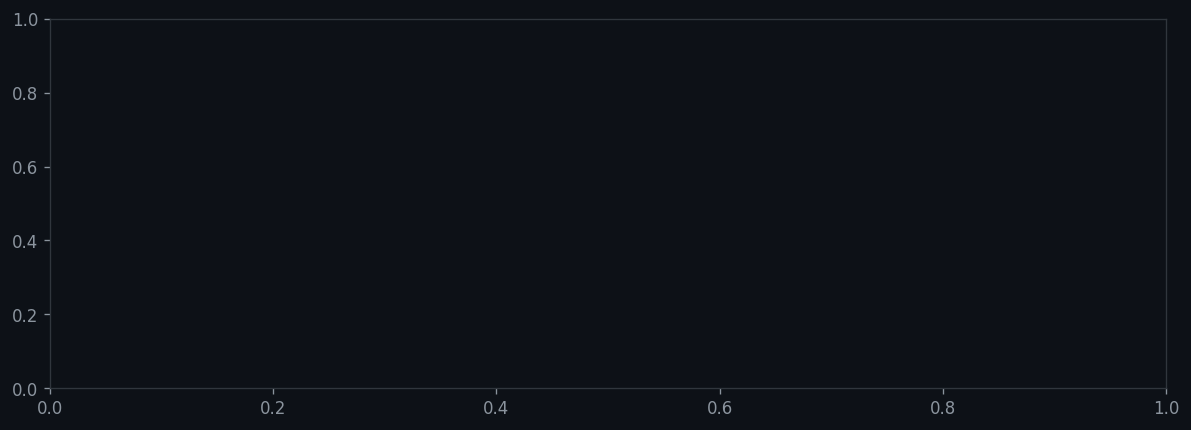

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

missing = df_train.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print('No missing values found.')
else:
    bars = ax.bar(missing.index, missing.values, color='#f85149', width=0.5)
    ax.set_ylabel('Missing %', color='#8b949e')
    ax.set_title('Missing Values by Feature', color='#c9d1d9', pad=12)
    ax.tick_params(colors='#8b949e')
    ax.set_xticks(range(len(missing)))
    ax.set_xticklabels(missing.index, rotation=30, ha='right', color='#c9d1d9')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    for bar, val in zip(bars, missing.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', color='#c9d1d9', fontsize=9)
    plt.tight_layout()
    plt.show()

## 7. Numerical Feature Distributions

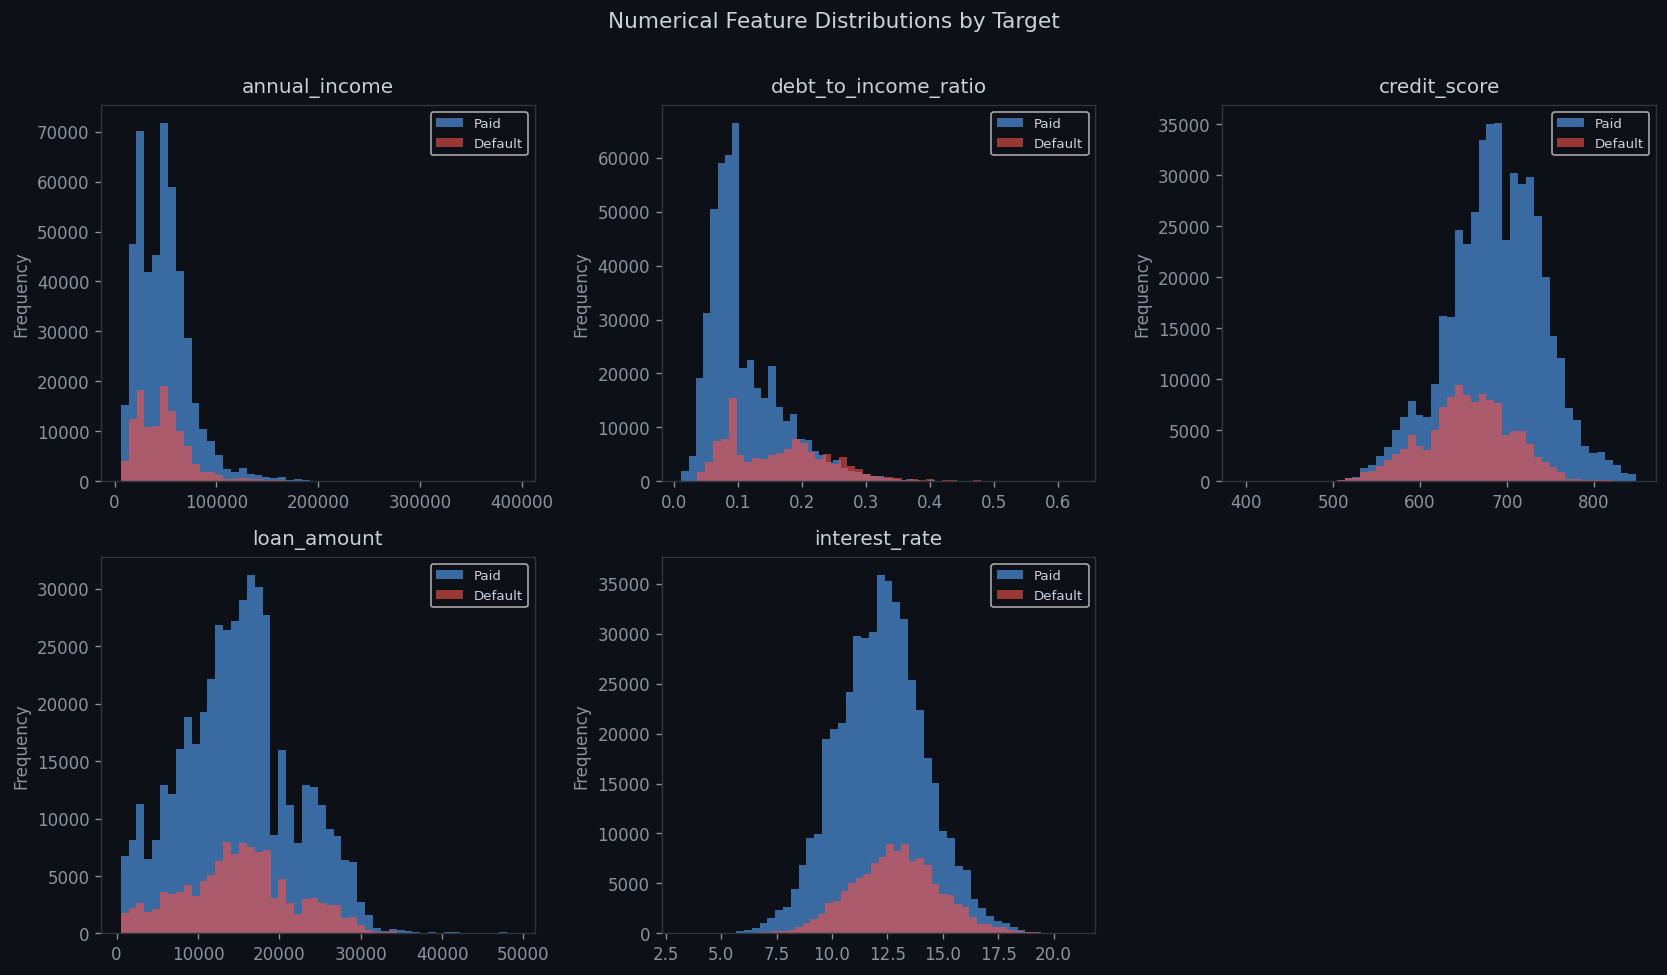

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.patch.set_facecolor('#0d1117')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.set_facecolor('#0d1117')
    df_train[df_train[TARGET_COL]==1][col].plot.hist(ax=ax, bins=50, alpha=0.6, color='#58a6ff', label='Paid')
    df_train[df_train[TARGET_COL]==0][col].plot.hist(ax=ax, bins=50, alpha=0.6, color='#f85149', label='Default')
    ax.set_title(col, color='#c9d1d9', pad=8)
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Target', color='#c9d1d9', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Correlation with Target

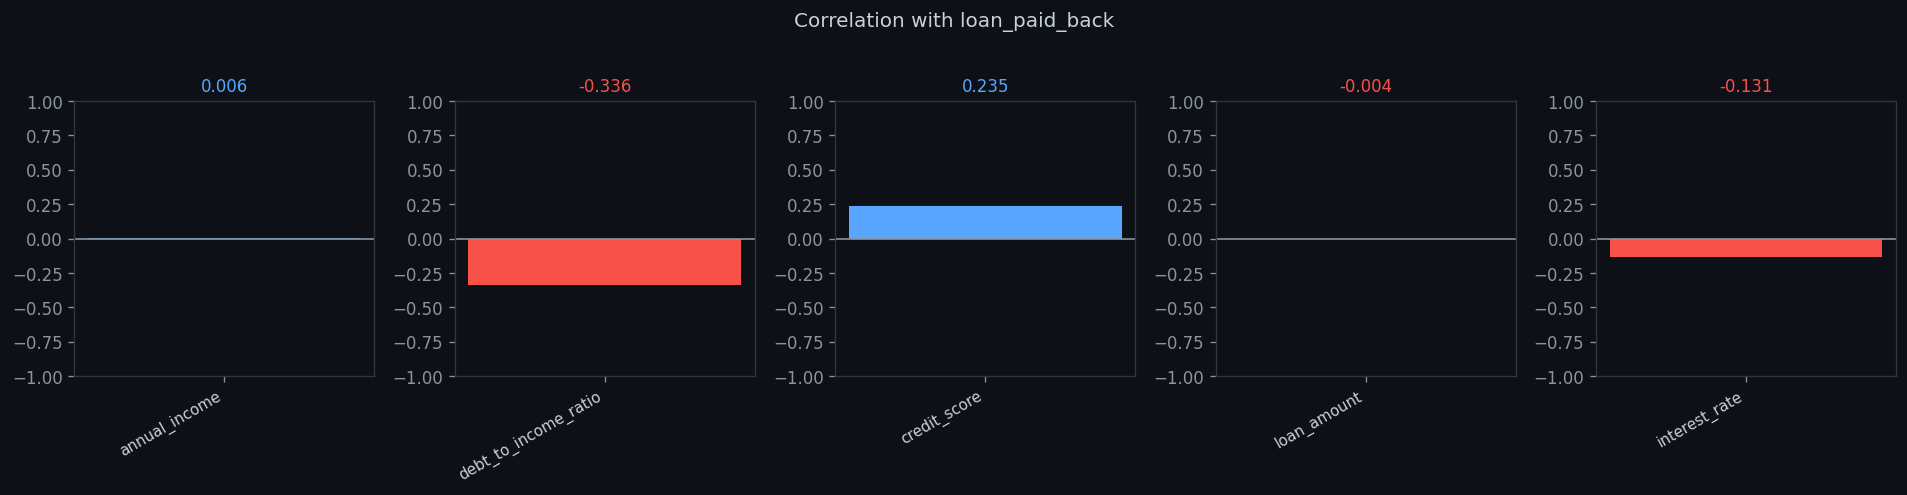

In [8]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 4))
fig.patch.set_facecolor('#0d1117')

for i, col in enumerate(num_cols):
    corr_val = df_train[col].corr(df_train[TARGET_COL])
    color = '#58a6ff' if corr_val >= 0 else '#f85149'
    ax = axes[i]
    ax.set_facecolor('#0d1117')
    ax.bar([col], [corr_val], color=color, width=0.5)
    ax.set_ylim(-1, 1)
    ax.axhline(0, color='#8b949e', linewidth=1)
    ax.set_title(f'{corr_val:.3f}', color=color, pad=6, fontsize=10)
    ax.tick_params(colors='#8b949e')
    ax.set_xticks([0])
    ax.set_xticklabels([col], rotation=30, ha='right', fontsize=9, color='#c9d1d9')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

plt.suptitle('Correlation with loan_paid_back', color='#c9d1d9', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 9. Categorical Feature Cardinality

In [9]:
pd.DataFrame({
    'unique_values': df_train[cat_cols].nunique(),
    'sample_values': [df_train[col].unique()[:3].tolist() for col in cat_cols]
}).sort_values('unique_values', ascending=False)

,unique_values,sample_values
grade_subgrade,30,"[C3, D3, C5]"
loan_purpose,8,"[Other, Debt consolidation, Home]"
employment_status,5,"[Self-employed, Employed, Unemployed]"
education_level,5,"[High School, Master's, Bachelor's]"
marital_status,4,"[Single, Married, Divorced]"
gender,3,"[Female, Male, Other]"


## 10. Default Rate by Categorical Feature

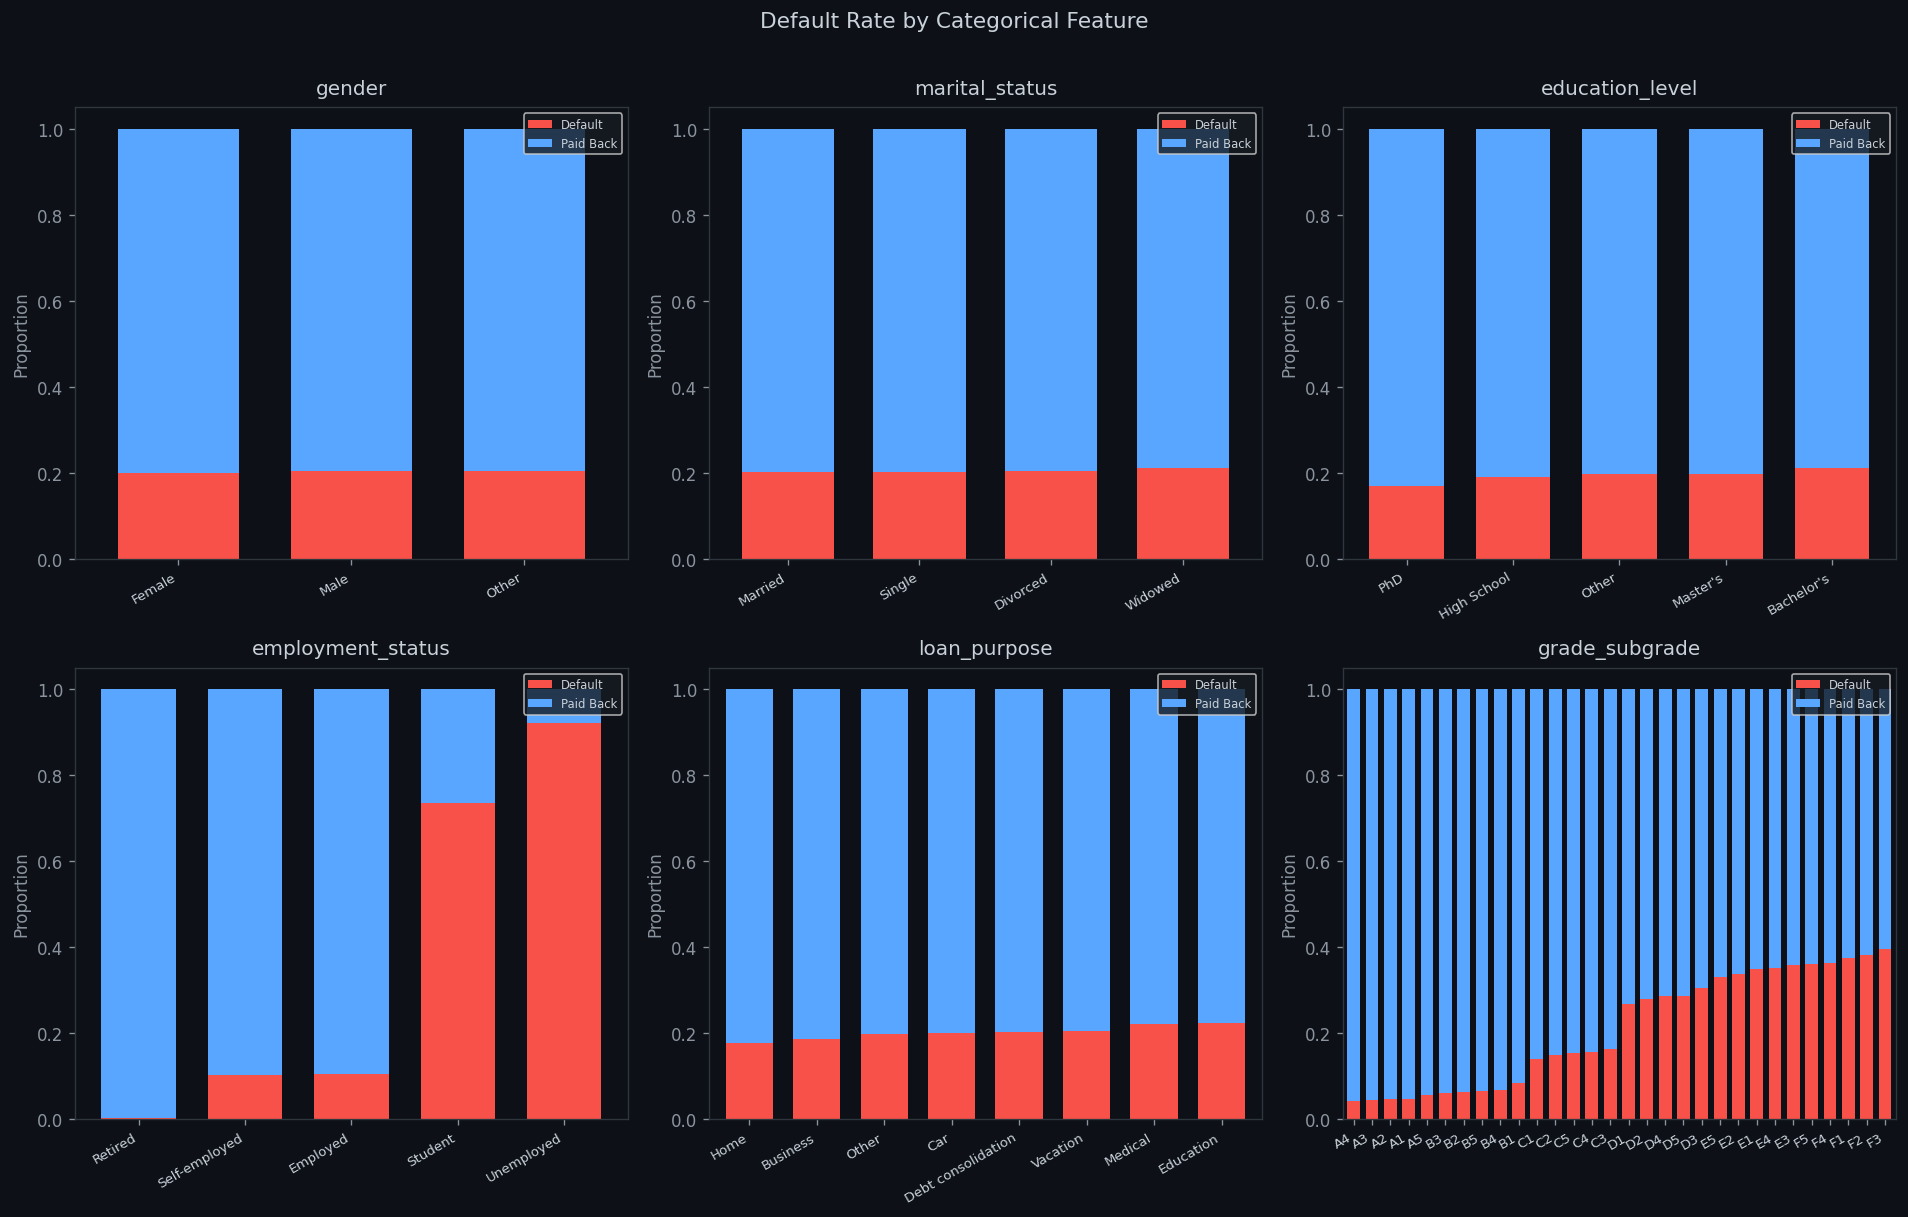

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    ax.set_facecolor('#0d1117')

    group = (df_train.groupby(col)[TARGET_COL]
             .value_counts(normalize=True)
             .unstack()
             .sort_values(0))

    group.plot(kind='bar', ax=ax, stacked=True,
               color=['#f85149', '#58a6ff'], width=0.7, edgecolor='none')

    ax.set_title(col, color='#c9d1d9', pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('Proportion', color='#8b949e')
    ax.tick_params(colors='#8b949e')
    ax.set_xticklabels(group.index, rotation=30, ha='right', color='#c9d1d9', fontsize=8)
    ax.legend(['Default', 'Paid Back'], facecolor='#161b22', labelcolor='#c9d1d9', fontsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Default Rate by Categorical Feature', color='#c9d1d9', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Key Findings

- **80/20 class imbalance** — requires stratified folds and class weighting in the model
- **No missing values** — unusual for real lending data, consistent with synthetic generation
- **`debt_to_income_ratio`** is the strongest single predictor (confirmed by feature importance)
- **`credit_score`** and **`loan_amount`** form the second tier of predictors
- **`grade_subgrade`** has a clean ordinal signal — A grades default least, F grades most
- **`gender`** and **`marital_status`** carry near-zero signal — dropped from final model
- **`employment_status`** is surprisingly predictive — stronger than `interest_rate`

See `src/train.py` for the full training pipeline.